<a href="https://colab.research.google.com/github/Tacnosuhel/Deep-Learning/blob/main/Deep_Learning_ANN_by_Krish_naik(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install tensorflow

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
# import some basic library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
dataset=pd.read_csv('Churn_Modelling.csv')

In [ ]:
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# devide data into dependent or independent variable
X=dataset.iloc[:,3:13]
y=dataset.iloc[:,13]

In [ ]:
# Feature engineering
geography=pd.get_dummies(X["Geography"],drop_first=True)
gender=pd.get_dummies(X["Gender"],drop_first=True)

In [ ]:
X.drop(["Geography","Gender"],inplace=True,axis=1)
X=pd.concat([X,geography,gender],axis=1)

In [ ]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [ ]:
# splitting the dataset into train and test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [ ]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)


In [ ]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [ ]:
# Note: ANN problem can solve by ml part

In [ ]:
# # part 2 Now let's create the ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

In [ ]:
# Let's initialize the ANN
classifier=Sequential()

In [ ]:
# Adding the input layer
classifier.add(Dense(units=11,activation='relu'))

In [ ]:
# adding the first hidden layer
classifier.add(Dense(units=7,activation='relu'))
classifier.add(Dropout(0.3))

In [ ]:
# add the second hidden layer
classifier.add(Dense(units=6,activation='relu'))
classifier.add(Dropout(0.3))

In [ ]:
# add the output layer
classifier.add(Dense(units=1,activation='sigmoid'))

In [ ]:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
# learning rate by default by adam is 0.01

In [ ]:
# we do mannually set learning rate by
# import tensorflow
# opt= tensorflow.keras.optimizers.Adam(learning_rate=0.001)
# and pass intead of optimizer='adam' write optimizer='opt'

In [ ]:
# Early stopping
import tensorflow as tf
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)


In [ ]:
# now train the neural network
model_history=classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.7962 - loss: 0.4907 - val_accuracy: 0.7955 - val_loss: 0.4544
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7962 - loss: 0.4355 - val_accuracy: 0.7955 - val_loss: 0.4358
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8013 - loss: 0.4218 - val_accuracy: 0.8065 - val_loss: 0.4260
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8197 - loss: 0.4129 - val_accuracy: 0.8133 - val_loss: 0.4211
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8231 - loss: 0.4064 - val_accuracy: 0.8171 - val_loss: 0.4174
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8272 - loss: 0.4001 - val_accuracy: 0.8251 - val_loss: 0.4077
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8326 - loss: 0.3936 - val_accuracy: 0.8213 - val_loss: 0.4063
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8384 - loss: 0.3870 

In [ ]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

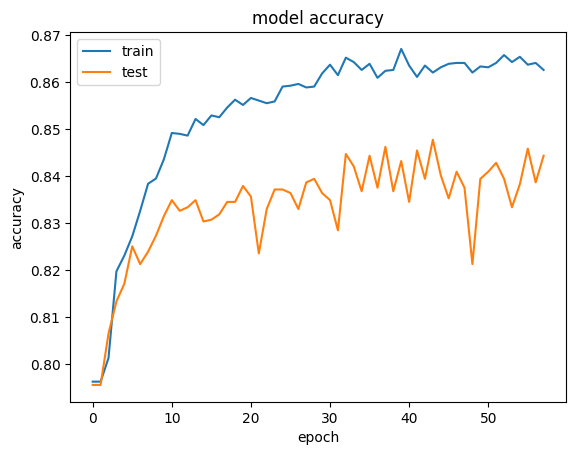

In [ ]:
# summaeize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

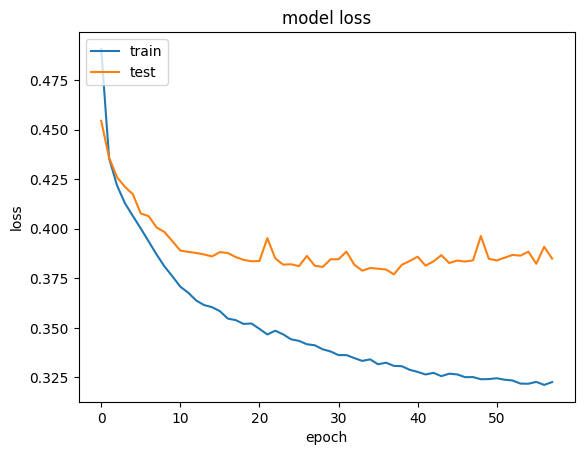

In [ ]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()


In [ ]:
# predicting the test set
y_pred=classifier.predict(X_test)
y_pred=(y_pred>0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# make confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[1506,   89],
       [ 196,  209]])

In [ ]:
# calculate the accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)
score

0.8575

In [ ]:
# get the weights from neuronse
classifier.get_weights()

[array([[-0.09245724, -0.5859594 ,  0.09730373, -0.5056487 ,  0.07128536,
          0.01220874,  0.1180812 ,  0.15203297,  0.8113027 ,  0.10065728,
         -0.04335226],
        [-0.04815207, -0.13808681, -0.39074597,  0.7984317 , -0.2596094 ,
          0.24826047,  0.03223487, -0.6904804 , -0.43346807, -0.04412602,
         -0.5995761 ],
        [ 0.09282368, -0.24850303,  0.09814436, -0.76986575,  0.09632806,
          0.03895073,  0.11617002, -0.32543945,  0.34472743, -0.05308009,
          0.05991243],
        [-0.48866972,  0.38217258, -0.24360575, -0.57951605, -0.33648312,
         -0.1405564 , -0.2423252 , -0.28946224,  0.5902277 , -0.25273025,
          0.15293097],
        [-0.37474415, -0.40621993, -0.19836713, -0.5688345 , -1.5090295 ,
         -0.3959826 , -0.2920925 , -0.29158598, -0.5495785 , -0.41895086,
         -0.44044706],
        [ 0.04745645, -0.12556735, -0.01720732, -0.297108  ,  0.06088065,
          0.08400659, -0.17081414,  0.08108106,  0.26535884,  0.0161199